# 10.2.2 Bode与Nyquist的读图条件

## 学习目标与先修知识

计算幅相与延迟（delay），区分稳定裕度和非线性闭环保证。

先修：10.2.1特征根、第6.2章频率响应（frequency response）及复数（complex number）；第4.5章稳定条件。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

给开环对象加纯延迟，频率响应的幅值可能不变，相位（phase）却继续落后。如何用Bode图观察这一变化？又为何不能仅凭正频率的一截曲线宣称满足Nyquist判据？

In [1]:
import math
import itertools
import ast
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

取ω=1/T、τ=0.5 T；比较延迟0与0.25 T下的幅值及相角。

In [2]:
for d in [0.,.25]:print("额外延迟相位 / 度：",d,-math.degrees(1.*d))

额外延迟相位 / 度： 0.0 -0.0
额外延迟相位 / 度： 0.25 -14.32394487827058


## 模型假设

开环 $L(s)=K e^{-sd}/[(s+1)(\tau s+1)]$，K>0、τ>0、d≥0。若 K=0，回路频响恒为零，幅值为零但相位没有定义；此时也没有有限的 dB 幅值读数。先用d=0的有理对象解释Nyquist几何；此时开环无右半平面极点（pole）且虚轴上无极点。纯延迟的幅相用于数值图，不把低阶延迟近似的极点自动当作原系统结论。频响相角输出（output）是atan2主值，绘图时显式展开。

## 数学解释与推导

在 $s=j\omega$，$|e^{-j\omega d}|=1$，相角贡献 $-\omega d$ 弧度。因此延迟不会改变开环幅值，却会改变交叉频率附近的相位。Bode幅值常用 $20\log_{10}|L(j\omega)|$ dB，相角必须说明是主值还是连续展开；主值在±180°附近跳变可只是显示分支。

在单一交叉的教学情形下，增益交叉频率（gain crossover frequency） $\omega_{gc}$ 满足 $|L(j\omega_{gc})|=1$；用在 $-180^\circ$ 附近连续展开的相角定义相位裕度（phase margin） $PM=180^\circ+\angle L(j\omega_{gc})$。相位交叉频率（phase crossover frequency） $\omega_{pc}$ 满足 $\angle L(j\omega_{pc})=-180^\circ$；相应增益裕度（gain margin） $GM=1/|L(j\omega_{pc})|$，也可记成 $20\log_{10}GM$ dB。若不存在相应交叉，不能硬套这个数值定义。

Nyquist使用完整闭合轮廓在复平面中绕过临界点−1。明确采取“内部在行进方向左侧”的正向右半平面轮廓，并把绕数N定义为 $1+L(s)$ 绕原点的反时针次数时，幅角原理给出 $N=Z-P$，其中P、Z分别是轮廓内开环极点数与闭环特征零点（zero）数。对d=0的本例P=0；图上只画有限的正负频率分支，不能由其独自替代完整轮廓和判据条件。

上述裕度反映该线性回路在这些交叉条件下的频域余量；饱和和未知高频动态不包含在这条曲线里。若有多重交叉或非常规开环结构，须检查所有相关交叉并回到完整 Nyquist 判据。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def frequency_point(gain, tau, omega, delay):
    """Magnitude and principal phase in degrees of K exp(-sd)/((s+1)(tau*s+1))."""
    value = gain * complex(math.cos(-omega * delay), math.sin(-omega * delay))
    value /= (1 + 1j * omega) * (1 + 1j * tau * omega)
    return abs(value), math.degrees(math.atan2(value.imag, value.real))

## 对照实验

在同一K、τ下画延迟前后的Bode幅值与展开相位，再画d=0的有限频率Nyquist分支。不要把两端截断处的空隙当成真实闭合轮廓。

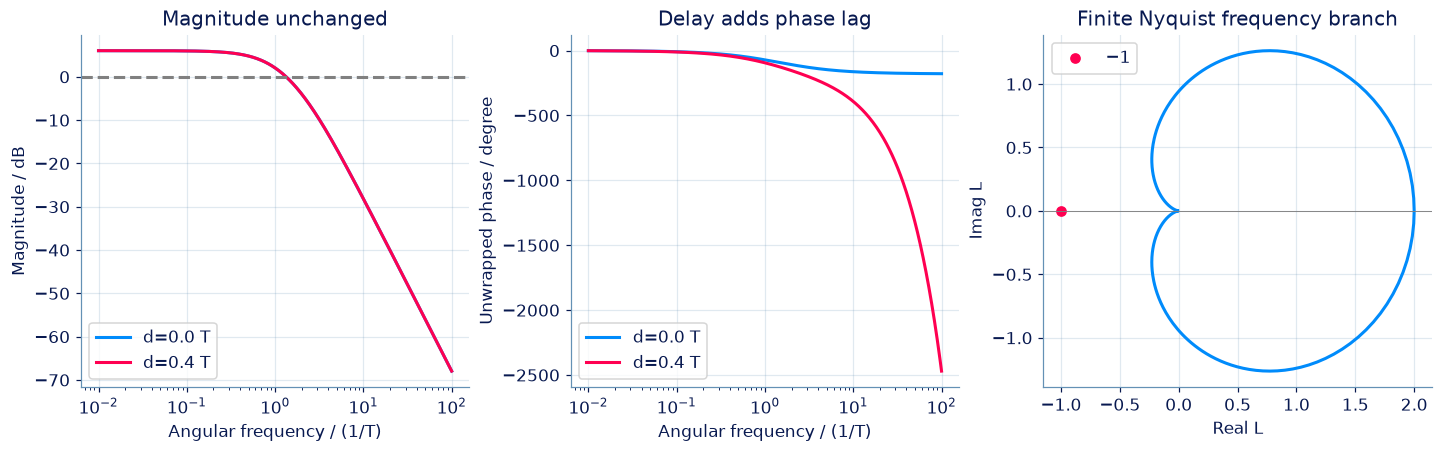

In [4]:
omega=np.logspace(-2,2,500);fig,axes=plt.subplots(1,3,figsize=(13,4))
for d,color in [(0.,BLUE),(.4,PINK)]:
    values=np.array([frequency_point(2.,.5,float(w),d) for w in omega])
    axes[0].semilogx(omega,20*np.log10(values[:,0]),label=f'd={d} T',color=color)
    axes[1].semilogx(omega,np.degrees(np.unwrap(np.radians(values[:,1]))),label=f'd={d} T',color=color)
axes[0].axhline(0,color='gray',ls='--');axes[0].set(xlabel='Angular frequency / (1/T)',ylabel='Magnitude / dB',title='Magnitude unchanged');axes[0].legend()
axes[1].set(xlabel='Angular frequency / (1/T)',ylabel='Unwrapped phase / degree',title='Delay adds phase lag');axes[1].legend()
w=np.linspace(-20,20,1201);loop=2/((1+1j*w)*(1+.5j*w))
axes[2].plot(loop.real,loop.imag,color=BLUE);axes[2].scatter([-1],[0],color=PINK,label='−1');axes[2].set(xlabel='Real L',ylabel='Imag L',title='Finite Nyquist frequency branch');axes[2].axhline(0,color='gray',lw=.6);axes[2].legend();plt.show()

## 结果解释

两条幅值曲线重合，延迟增加相位落后。右图只显示有限频率分支与−1位置；本节特定d=0对象稳定性还可以用10.2.1的闭环多项式独立确认。纯延迟或不同高阶近似时，应重查完整模型（model）、轮廓条件与数值误差（numerical error）。

### 独立核对

在多个频率直接比较有/无延迟的复数模长（modulus），并确认闭环低阶根全部在左半平面；相角折返用展开算法检查。

In [5]:
for w in [.1,1.,10.]:
    no_delay=frequency_point(2.,.5,w,0.)
    delayed=frequency_point(2.,.5,w,.4)
    np.testing.assert_allclose(no_delay[0],delayed[0],atol=1e-12)
assert max(np.roots([.5,1.5,3.]).real)<0
print('纯延迟模长不变，低阶无延迟闭环根在左半平面。')

纯延迟模长不变，低阶无延迟闭环根在左半平面。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/10-02-%E9%A2%91%E5%9F%9F%E7%A8%B3%E5%AE%9A%E6%80%A7%E4%B8%8E%E8%AE%BE%E8%AE%A1/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：计算回路频率响应

开环 L(s)=K e^(−sd)/[(s+1)(τs+1)]，其中 K>0。在题给非负角频率计算幅值及主值相角（度，范围(−180,180]；恰在分支端点按 atan2 结果）。

**函数与代码模板**

```python
def solve(
    gain: float,
    tau: float,
    omega: float,
    delay: float,
) -> tuple[float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `gain` | `float` | 正实增益（gain）；K=0 时频响相位（phase）不定义。 | 1 |
| `tau` | `float` | 正时间常数。 | T |
| `omega` | `float` | 角频率。 | 1/T |
| `delay` | `float` | 非负纯延迟（delay）。 | T |

**返回值**

按以下顺序返回元组：(magnitude, phase_deg)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `magnitude` | `float` | 复频响模长（modulus）。 | 1 |
| `phase_deg` | `float` | atan2 主值相角。 | degree |

**计算规则**

直接以复数（complex number） jω 代入，并乘 exp(−jωd)。不要把主值相角当成自动展开的连续相位（phase）。 K=0 时幅值为零、相位无定义，不在本题输入（input）范围内。

**约束与边界**

- 输入（input）均为有限实数，且 gain>0、tau>0、omega≥0、delay≥0；只需实现题定模型（model），不外推到真实病人或设备。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| gain | 正实增益（gain）；K=0 时频响相位（phase）不定义。 | 1 | 1 |
| tau | 正时间常数。 | 1 | T |
| omega | 角频率。 | 0 | 1/T |
| delay | 非负纯延迟（delay）。 | 0 | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
gain = 1.0
tau = 1.0
omega = 0.0
delay = 0.0

result = solve(gain, tau, omega, delay)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| magnitude | 复频响模长（modulus）。 | 1 | 1 |
| phase_deg | atan2 主值相角。 | 0 | degree |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (1.0, 0.0)
```

**样例解释**

延迟乘子模长为1，相位贡献−ωd弧度；相角输出（output）可能折回，不能把一次折回误读为系统突变。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：计算回路频率响应](http://127.0.0.1:8000/chapters/10-02-%E9%A2%91%E5%9F%9F%E7%A8%B3%E5%AE%9A%E6%80%A7%E4%B8%8E%E8%AE%BE%E8%AE%A1/practice/?question=p10-frequency-delay)

### 第 2 题 · 多项选择题：Nyquist 判据的边界

应用 Nyquist 判据前，已明确开环轮廓上没有极点（pole）且固定绕数方向约定。还应知道什么？

- **A.** 开环右半平面极点数，并跟踪−1点绕数。
- **B.** 只观察正频率曲线的一个点。
- **C.** 任何非线性饱和系统都与线性回路结论相同。
- **D.** 若改变轮廓或绕数方向，公式符号也须同步核对。

[作答：Nyquist 判据的边界](http://127.0.0.1:8000/chapters/10-02-%E9%A2%91%E5%9F%9F%E7%A8%B3%E5%AE%9A%E6%80%A7%E4%B8%8E%E8%AE%BE%E8%AE%A1/practice/?question=p10-nyquist-hypotheses)

### 第 3 题 · 单项选择题：裕度能说明什么

给定线性开环模型（model）的 Bode 图和正相位裕度（phase margin）。哪项判断最谨慎？

- **A.** 这提供该线性回路在相应交叉频率条件下的频域稳定裕度与鲁棒性信息，还需检查噪声、饱和与失配。
- **B.** 正裕度证明全部初态和非线性约束下都安全。
- **C.** 相位裕度与延迟（delay）无关。
- **D.** 幅值和相位（phase）都不需注明单位或频率。

[作答：裕度能说明什么](http://127.0.0.1:8000/chapters/10-02-%E9%A2%91%E5%9F%9F%E7%A8%B3%E5%AE%9A%E6%80%A7%E4%B8%8E%E8%AE%BE%E8%AE%A1/practice/?question=p10-bode-margin)

### 第 4 题 · 单项选择题：主值相角与连续相位

某频点主值相角从−179°跳到+179°。下列哪项最合理？

- **A.** 这可能只是相角绕过分支切线（tangent line）；应展开相位（phase）再讨论连续趋势。
- **B.** 对象一定发生物理跳变。
- **C.** 频响幅值必同时跃迁无穷大。
- **D.** 任何主值跳变都说明闭环不稳定。

[作答：主值相角与连续相位](http://127.0.0.1:8000/chapters/10-02-%E9%A2%91%E5%9F%9F%E7%A8%B3%E5%AE%9A%E6%80%A7%E4%B8%8E%E8%AE%BE%E8%AE%A1/practice/?question=p10-phase-wrap)

**进一步阅读**

[MIT OpenCourseWare，Feedback Control Systems 课程讲义](https://ocw.mit.edu/courses/16-30-feedback-control-systems-fall-2010/pages/lecture-notes/)：按主题阅读 PID、频域、能控、观测器和线性二次调节；本教材的模型与数值为独立教学例。